In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")


In [121]:
from dotenv import load_dotenv
import os
import pandas as pd
from pathlib import Path
# google.colab.drive is only imported if IN_COLAB is True

# --- Configuration for Dataset Folder ---
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # In Colab, default to /content/ for data storage
    DATASET_FOLDER = os.getenv("DATASET_FOLDER", "/content/")
else:
    # Outside Colab, default to a local 'data' directory in the current working directory
    # Users can set the DATASET_FOLDER environment variable or modify the .env file to change this.
    DATASET_FOLDER = os.getenv("DATASET_FOLDER", "./data/")

dataset_path = Path(DATASET_FOLDER)

# --- Mount Google Drive and Download Files (Colab only) ---
if IN_COLAB:
    from google.colab import drive # Import drive only if in Colab
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Install gdown if not already installed
    try:
        import gdown
    except ImportError:
        print("gdown not found. Installing gdown...")
        !pip install gdown -q
        import gdown

    # Google Drive folder ID (extracted from the provided URL)
    # URL: https://drive.google.com/drive/folders/1PmLapJI1VSDgvl_AxARNKwM1MCd3WFX0
    GOOGLE_DRIVE_FOLDER_ID = '1PmLapJI1VSDgvl_AxARNKwM1MCd3WFX0'

    # Download contents of the Google Drive folder to the specified dataset folder
    print(f"\nDownloading files from Google Drive folder ID: {GOOGLE_DRIVE_FOLDER_ID} to {DATASET_FOLDER}")

    # Ensure the target directory exists before downloading
    dataset_path.mkdir(parents=True, exist_ok=True)

    # Use gdown to download all files from the folder to the target directory
    # For folder IDs, gdown downloads contents into the current working directory.
    # We ensure the current working directory is the DATASET_FOLDER before downloading.
    current_cwd = os.getcwd()
    os.chdir(DATASET_FOLDER) # Change to the dataset folder
    !gdown --id $GOOGLE_DRIVE_FOLDER_ID --fuzzy --no-check-certificate
    os.chdir(current_cwd) # Change back to original working directory
    print(f"Files downloaded successfully to {DATASET_FOLDER}")
else:
    print(f"Not in Google Colab environment. Skipping Google Drive mount and gdown download.")
    print(f"Expecting dataset files to be located in: {DATASET_FOLDER}")

# Ensure the dataset directory exists (for both Colab and local environments)
if not dataset_path.exists():
    dataset_path.mkdir(parents=True, exist_ok=True)
    print(f"Created directory: {dataset_path}")
else:
    print(f"Directory already exists: {dataset_path}")

# Create a sample .env file for demonstration purposes
env_content = f"""
# --- Dataset File Paths ---
# This DATASET_FOLDER variable determines where the data files are expected to be.
# If running outside Colab, you can change this to your local data directory.
# Example: DATASET_FOLDER=./my_local_data_folder/
# The paths below will automatically adjust based on DATASET_FOLDER.

DATASET_FOLDER={DATASET_FOLDER}
CUSTOMERS_FILE={DATASET_FOLDER}customers.csv
ORDERS_FILE={DATASET_FOLDER}orders.csv
WEB_FILE={DATASET_FOLDER}web_events_snapshot.csv
LABELS_FILE={DATASET_FOLDER}churn_labels.csv
INTERVENTIONS_FILE={DATASET_FOLDER}intervention_history.csv
TICKETS_FILE={DATASET_FOLDER}support_tickets.csv
"""

with open(".env", "w") as f:
    f.write(env_content)

print("A sample .env file has been created/updated in the current directory.")
print("Content of .env file:\n" + env_content)

# Load .env file
load_dotenv()

# Base path for fallback (now dynamic based on environment)
base_path = dataset_path

# Define file paths, prioritizing environment variables, then the determined base_path
customers_path = os.getenv("CUSTOMERS_FILE", str(base_path / "customers.csv"))
orders_path = os.getenv("ORDERS_FILE", str(base_path / "orders.csv"))
web_path = os.getenv("WEB_FILE", str(base_path / "web_events_snapshot.csv"))
labels_path = os.getenv("LABELS_FILE", str(base_path / "churn_labels.csv"))
interventions_path = os.getenv("INTERVENTIONS_FILE", str(base_path / "intervention_history.csv"))
tickets_path = os.getenv("TICKETS_FILE", str(base_path / "support_tickets.csv"))

print("\nUsing paths:")
print(f"  Customers: {customers_path}")
print(f"  Orders: {orders_path}")
print(f"  Web: {web_path}")
print(f"  Labels: {labels_path}")
print(f"  Interventions: {interventions_path}")
print(f"  Tickets: {tickets_path}")


# Load datasets with error handling for FileNotFoundError
try:
    customers = pd.read_csv(customers_path)
    orders = pd.read_csv(orders_path)
    web = pd.read_csv(web_path)
    labels = pd.read_csv(labels_path)
    interventions = pd.read_csv(interventions_path)
    tickets = pd.read_csv(tickets_path)

    datasets = {
        'customers': customers,
        'orders': orders,
        'web': web,
        'labels': labels,
        'interventions': interventions,
        'tickets': tickets
    }

    for name, df in datasets.items():
        print('\n', '='*40)
        print(name.upper())
        print(df.info())
        print(df.describe(include='all'))

except FileNotFoundError as e:
    print(f"\nError loading dataset: {e}")
    print(f"Please ensure the data files are present in the specified directory: {DATASET_FOLDER}")
    if not IN_COLAB:
        print(f"If running outside Colab, you might need to manually place the files in {DATASET_FOLDER} or update the DATASET_FOLDER variable in your .env file or directly in the script.")
except Exception as e:
    print(f"\nAn unexpected error occurred during data loading: {e}")

Not in Google Colab environment. Skipping Google Drive mount and gdown download.
Expecting dataset files to be located in: ./data/
Directory already exists: data
A sample .env file has been created/updated in the current directory.
Content of .env file:

# --- Dataset File Paths ---
# This DATASET_FOLDER variable determines where the data files are expected to be.
# If running outside Colab, you can change this to your local data directory.
# Example: DATASET_FOLDER=./my_local_data_folder/
# The paths below will automatically adjust based on DATASET_FOLDER.

DATASET_FOLDER=./data/
CUSTOMERS_FILE=./data/customers.csv
ORDERS_FILE=./data/orders.csv
WEB_FILE=./data/web_events_snapshot.csv
LABELS_FILE=./data/churn_labels.csv
INTERVENTIONS_FILE=./data/intervention_history.csv
TICKETS_FILE=./data/support_tickets.csv


Using paths:
  Customers: ./data/customers.csv
  Orders: ./data/orders.csv
  Web: ./data/web_events_snapshot.csv
  Labels: ./data/churn_labels.csv
  Interventions: ./data/interv

Data can be imported and saved in local at runtime.Code is made to work with Colab to download data in content folder automatically or manually place csv file in data folder when running in local environment.Using dvc pipeline is not mandatory as per requirement, so manual data movement into project data folder is suggested, to keep data out of github environment.

Saved chart: charts\churn_distribution_bar.png


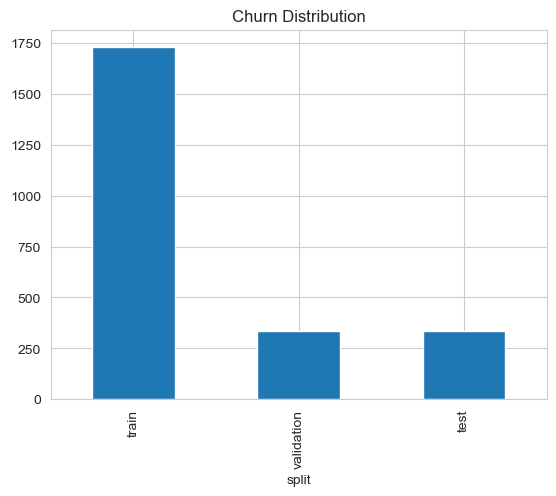

Saved chart: charts\top_ticket_categories_bar.png


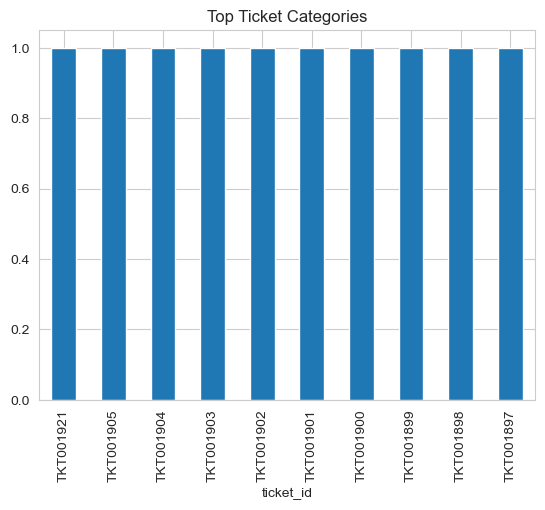

Saved chart: charts\top_web_events_bar.png


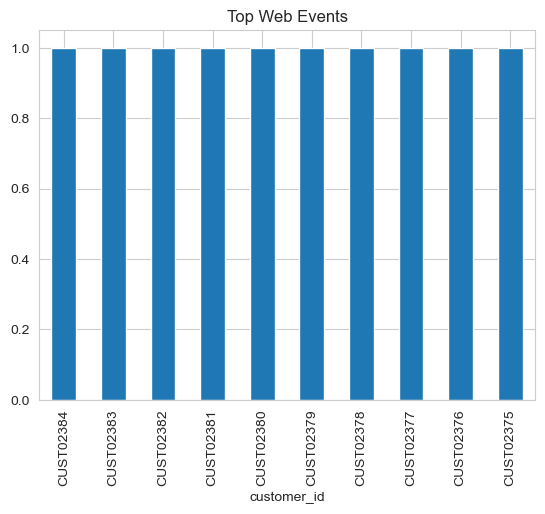

Saved chart: charts\top_ticket_categories_bar.png


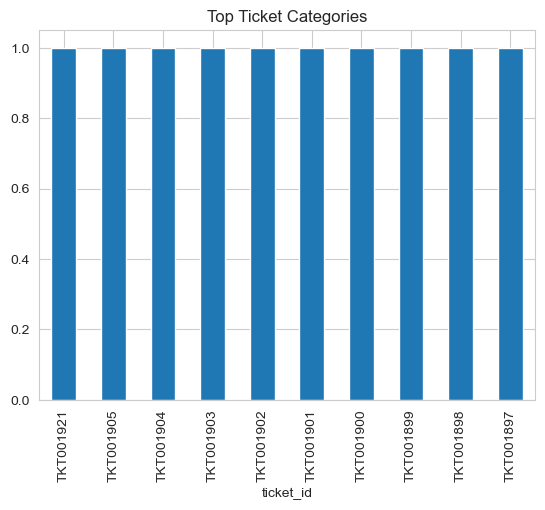

Saved chart: charts\top_web_events_bar.png


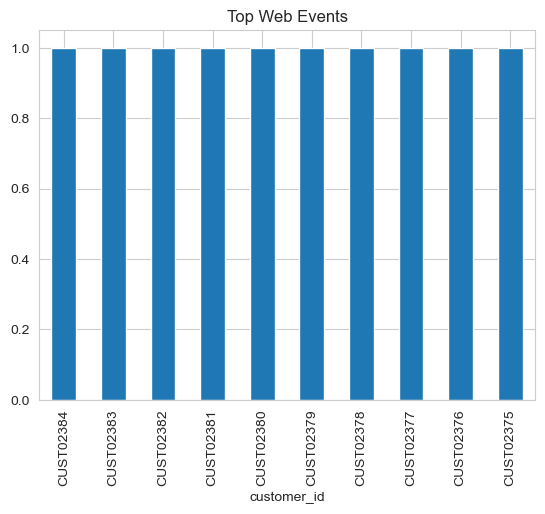

In [122]:
labels.iloc[:, -1].value_counts().plot(kind='bar', title='Churn Distribution')
def save_chart(filename, folder=Path("charts")):
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    filepath = folder / filename
    plt.savefig(filepath, bbox_inches='tight')
    print(f"Saved chart: {filepath}")

labels.iloc[:, -1].value_counts().plot(kind='bar', title='Churn Distribution')
save_chart('churn_distribution_bar.png')
plt.show()

plt.figure()
tickets.iloc[:, 0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Ticket Categories')
save_chart('top_ticket_categories_bar.png')
plt.show()

plt.figure()
web.iloc[:, 0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Web Events')
save_chart('top_web_events_bar.png')
plt.show()
plt.show()

plt.figure() # Create a new figure for the next plot
tickets.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Ticket Categories')
save_chart('top_ticket_categories_bar.png')
plt.show()

plt.figure() # Create a new figure for the next plot
web.iloc[:,0].astype(str).value_counts().head(10).plot(kind='bar', title='Top Web Events')
save_chart('top_web_events_bar.png')
plt.show()

Saved chart: charts\missing_value_percentage.png


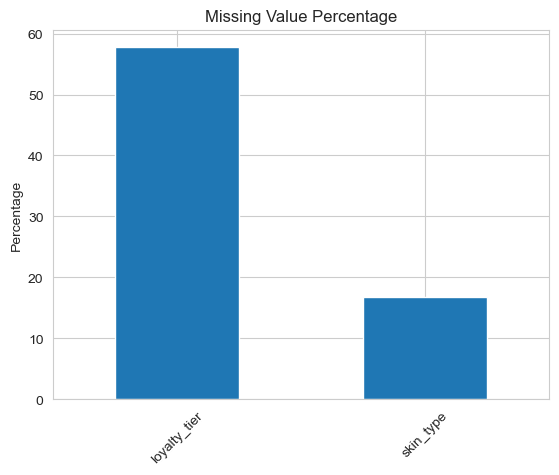

In [123]:
missing = customers.isnull().mean().sort_values(ascending=False) * 100

missing = missing[missing > 0]

missing.plot(kind='bar')

plt.title("Missing Value Percentage")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
save_chart('missing_value_percentage.png')
plt.show()

In [124]:
duplicates = customers.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [125]:
import pandas as pd
import numpy as np
from pathlib import Path

# Assuming 'datasets' dictionary holds all dataframes as loaded in previous cells
# For robustness, redefine if datasets isn't globally available or is modified.
# In this specific context, 'datasets' is available.

dataframes = {
    'customers': customers,
    'orders': orders,
    'web': web,
    'labels': labels,
    'interventions': interventions,
    'tickets': tickets
}

print("--- Starting Data Quality Checks ---")

# Prepare content for the Markdown report
report_content = """
# Data Quality Report

This report summarizes the data quality checks performed on the various datasets.

## 1. Duplicate Records
"""

# 1.1 Overall Row Duplicates per DataFrame
report_content += "### 1.1 Overall Row Duplicates per DataFrame\n"
print("\n--- Checking Overall Row Duplicates per DataFrame ---")
for name, df in dataframes.items():
    total_duplicates = df.duplicated().sum()
    report_content += f"- **{name.upper()} DataFrame (exact row duplicates)**: {total_duplicates} exact duplicate rows found.\n"
    if total_duplicates > 0:
        report_content += "  Sample duplicates:\n```\n"
        report_content += df[df.duplicated(keep=False)].head().to_string()
        report_content += "\n```\n"
    print(f"Overall Duplicates in {name.upper()}: {total_duplicates}")

# 1.2 Key ID Uniqueness Checks (originally part of section 3 'Join/Key Issues')
report_content += "\n### 1.2 Key ID Uniqueness Checks\n"
print("\n--- Checking Key ID Uniqueness ---")
# Check for duplicate customer_id in primary customer table
if customers['customer_id'].duplicated().any():
    report_content += f"- **Warning**: Duplicate 'customer_id' found in 'customers' table.\n```\n{customers[customers['customer_id'].duplicated(keep=False)].sort_values('customer_id').to_string()}\n```\n"
    print(f"Warning: Duplicate 'customer_id' found in 'customers' table.")
    print(customers[customers['customer_id'].duplicated(keep=False)].sort_values('customer_id'))
else:
    report_content += "- No duplicate 'customer_id' found in 'customers' table (good). All customers are unique.\n"
    print("No duplicate 'customer_id' found in 'customers' table (good). All customers are unique.")

# Check for uniqueness of other key IDs
key_checks = {
    'orders': 'order_id',
    'web': 'event_id',
    'interventions': 'intervention_id',
    'tickets': 'ticket_id'
}
for df_name, key_col in key_checks.items():
    if key_col in dataframes[df_name].columns:
        if dataframes[df_name][key_col].duplicated().any():
            report_content += f"- **Warning**: Duplicate '{key_col}' found in '{df_name}' table. Sample duplicates:\n```\n{dataframes[df_name][dataframes[df_name][key_col].duplicated(keep=False)].sort_values(key_col).head().to_string()}\n```\n"
            print(f"Warning: Duplicate '{key_col}' found in '{df_name}' table. Sample duplicates:")
            print(dataframes[df_name][dataframes[df_name][key_col].duplicated(keep=False)].sort_values(key_col).head())
        else:
            report_content += f"- No duplicate '{key_col}' found in '{df_name}' table (good). All {key_col}s are unique.\n"
            print(f"No duplicate '{key_col}' found in '{df_name}' table (good). All {key_col}s are unique.")
    else:
        report_content += f"- Column '{key_col}' not found in '{df_name}' table to check for duplicates.\n"
        print(f"Column '{key_col}' not found in '{df_name}' table to check for duplicates.")


## 2. Missing Values
report_content += "\n## 2. Missing Values\n"
print("\n--- Checking Missing Values per DataFrame ---")
for name, df in dataframes.items():
    report_content += f"\n### {name.upper()} DataFrame: Missing Values Overview\n"
    print(f"\n--- {name.upper()}: Missing Values Overview ---")
    missing_values = df.isnull().sum()
    missing_values = missing_values[missing_values > 0]
    if not missing_values.empty:
        report_content += f"- **Columns with missing values (count and percentage):**\n"
        report_content += "```\n"
        missing_df = pd.DataFrame({
            'Count': missing_values,
            'Percentage': (missing_values / len(df) * 100).round(2)
        })
        report_content += missing_df.to_string()
        report_content += "\n```\n"
        print(f"Missing values in {name.upper()}:\n{missing_df}")
    else:
        report_content += "- No missing values found in this DataFrame.\n"
        print(f"No missing values found in {name.upper()}.")


## 3. Invalid or Unusual Values (Categorical/Object Columns)
report_content += "\n## 3. Invalid or Unusual Values (Categorical/Object Columns)\n"
for name, df in dataframes.items():
    report_content += f"\n### {name.upper()} DataFrame: Categorical/Object Column Value Checks\n"
    print(f"\n--- Checking DataFrame: {name.upper()} ---")

    # 3.1 Invalid or Unusual Values (Categorical/Object columns)
    print(f"\n--- {name.upper()}: Categorical/Object Column Value Checks ---")
    object_cols = df.select_dtypes(include='object').columns
    if not object_cols.empty:
        for col in object_cols:
            if df[col].nunique() < 50: # Check only for columns with reasonable number of unique values
                report_content += f"\n- **Column '{col}' value counts:**\n```\n{df[col].value_counts(dropna=False).to_string()}\n```\n"
                print(f"\nColumn '{col}' value counts:")
                print(df[col].value_counts(dropna=False))
                # Specific checks for common issues (e.g., 'Unknown', 'N/A')
                if any(val in df[col].unique() for val in ['Unknown', 'N/A', 'None', 'null', 'nan']):
                    report_content += f"  - **Warning**: '{col}' contains 'Unknown', 'N/A', 'None', 'null', or 'nan' string values.\n"
                    print(f"  --> Warning: '{col}' contains 'Unknown', 'N/A', 'None', 'null', or 'nan' string values.")
            else:
                report_content += f"\n- Column '{col}' has too many unique values ({df[col].nunique()}) to display value counts directly. Top 10 values shown:\n"
                report_content += f"```\n{df[col].value_counts(dropna=False).head(10).to_string()}\n```\n"
                print(f"\nColumn '{col}' has too many unique values ({df[col].nunique()}). Top 10 values:")
                print(df[col].value_counts(dropna=False).head(10))
    else:
        report_content += f"  - No object/categorical columns found in {name.upper()} to check.\n"

    # 3.2 Outliers & Unusual Values (Numerical columns)
    report_content += f"\n### {name.upper()} DataFrame: Numerical Column Outlier/Range Checks\n"
    print(f"\n--- {name.upper()}: Numerical Column Outlier/Range Checks ---")
    numerical_cols = df.select_dtypes(include=np.number).columns
    if not numerical_cols.empty:
        report_content += f"\n- **Descriptive statistics for numerical columns:**\n```\n{df[numerical_cols].describe().to_string()}\n```\n"
        print("Descriptive statistics for numerical columns:")
        print(df[numerical_cols].describe())
        for col in numerical_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            if not outliers.empty:
                report_content += f"  - **Potential outliers detected in '{col}'**: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%) out of {len(df)} total rows.\n"
                report_content += f"    Sample outliers:\n```\n{outliers[[col]].head().to_string()}\n```\n"
                print(f"\n  Potential outliers detected in '{col}': {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%) out of {len(df)} total rows.")
                print("  Sample outliers:")
                print(outliers[[col]].head())
            # Check for negative values where not expected
            if (df[col] < 0).any():
                report_content += f"  - **Warning**: Negative values found in '{col}' (check if expected).\n"
                print(f"  --> Warning: Negative values found in '{col}' (check if expected).")
    else:
        report_content += f"  - No numerical columns found in {name.upper()} to check for outliers.\n"


## 4. Referential Integrity Checks (Join/Key Issues)
report_content += "\n## 4. Referential Integrity Checks (Join/Key Issues)\n"
print("\n--- Checking Referential Integrity Issues ---")

# Referential integrity (customer_id presence)
customer_ids_main = set(customers['customer_id'].unique())
for name, df in dataframes.items():
    if name != 'customers' and 'customer_id' in df.columns:
        customer_ids_df = set(df['customer_id'].unique())
        missing_in_main = customer_ids_df - customer_ids_main
        missing_in_df = customer_ids_main - customer_ids_df
        if missing_in_main:
            report_content += f"- **Warning**: {len(missing_in_main)} 'customer_id' in '{name}' are not found in 'customers' table. This indicates potential referential integrity issues.\n"
            report_content += f"  Sample missing customer_ids from '{name}': {list(missing_in_main)[:5]}...\n"
            print(f"Warning: {len(missing_in_main)} 'customer_id' in '{name}' are not found in 'customers' table. This indicates potential referential integrity issues.")
            print(f"  Sample missing customer_ids from '{name}': {list(missing_in_main)[:5]}...")
        if missing_in_df:
            report_content += f"- **Note**: {len(missing_in_df)} 'customer_id' in 'customers' are not found in '{name}' table. This is normal if not all customers have entries in this table (e.g., no orders, no web events).\n"
            report_content += f"  Sample customer_ids from 'customers' not in '{name}': {list(missing_in_df)[:5]}...\n"
            print(f"Note: {len(missing_in_df)} 'customer_id' in 'customers' are not found in '{name}' table. This is normal if not all customers have entries in this table (e.g., no orders, no web events).")
            print(f"  Sample customer_ids from 'customers' not in '{name}': {list(missing_in_df)[:5]}...")


## 5. Date Consistency Issues
report_content += "\n## 5. Date Consistency Issues\n"
print("\n--- Checking Date Consistency Issues ---")

date_cols_map = {
    'customers': ['signup_date'],
    'orders': ['order_date', 'delivery_date'],
    'web': ['event_timestamp'],
    'interventions': ['intervention_date'],
    'tickets': ['ticket_date']
}

for name, df in dataframes.items():
    report_content += f"\n### DataFrame: {name.upper()}\n"
    print(f"\nDataFrame: {name.upper()}")
    for col in date_cols_map.get(name, []):
        if col in df.columns:
            original_dtype = df[col].dtype
            try:
                # Convert to datetime, coercing errors to NaT
                df[col] = pd.to_datetime(df[col], errors='coerce')
                invalid_dates = df[df[col].isnull()]
                if not invalid_dates.empty:
                    report_content += f"  - **Warning**: Invalid date formats found in '{col}' (DataFrame: {name}). {len(invalid_dates)} rows converted to NaT.\n"
                    report_content += f"    Sample rows with invalid dates:\n```\n{invalid_dates[[col]].head().to_string()}\n```\n"
                    print(f"  Warning: Invalid date formats found in '{col}' (DataFrame: {name}). {len(invalid_dates)} rows converted to NaT.")
                    print("  Sample rows with invalid dates:")
                    print(invalid_dates[[col]].head())

                future_dates = df[df[col] > pd.Timestamp.now()]
                if not future_dates.empty:
                    report_content += f"  - **Warning**: Future dates found in '{col}' (DataFrame: {name}). Count: {len(future_dates)}\n"
                    report_content += f"    Sample future dates:\n```\n{future_dates[[col]].head().to_string()}\n```\n"
                    print(f"  Warning: Future dates found in '{col}' (DataFrame: {name}). Count: {len(future_dates)}")
                    print("  Sample future dates:")
                    print(future_dates[[col]].head())

            except Exception as e:
                report_content += f"  - **Error**: Error converting '{col}' in '{name}' to datetime: {e}\n"
                print(f"  Error converting '{col}' in '{name}' to datetime: {e}")
            finally:
                # Restore original dtype if it was changed for consistency if needed later
                # For this analysis, keeping as datetime is fine for subsequent checks
                pass

    # Specific checks for 'orders' delivery vs order date
    if name == 'orders' and 'order_date' in df.columns and 'delivery_date' in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df['order_date']) and pd.api.types.is_datetime64_any_dtype(df['delivery_date']):
            inconsistent_delivery = df[df['delivery_date'] < df['order_date']]
            if not inconsistent_delivery.empty:
                report_content += f"  - **Warning**: Inconsistent delivery dates (delivery_date < order_date) found in 'orders'. Count: {len(inconsistent_delivery)}\n"
                report_content += f"    Sample inconsistent delivery dates:\n```\n{inconsistent_delivery[['order_date', 'delivery_date']].head().to_string()}\n```\n"
                print(f"  Warning: Inconsistent delivery dates (delivery_date < order_date) found in 'orders'. Count: {len(inconsistent_delivery)}")
                print("  Sample inconsistent delivery dates:")
                print(inconsistent_delivery[['order_date', 'delivery_date']].head())
        else:
            report_content += f"  - Skipping delivery_date vs order_date check for 'orders' due to non-datetime columns.\n"
            print(f"  Skipping delivery_date vs order_date check for 'orders' due to non-datetime columns.")

    # Specific check for intervention_date consistency relative to signup_date
    if name == 'interventions' and 'intervention_date' in df.columns and 'signup_date' in customers.columns:
        # Ensure 'signup_date' in customers is also datetime for a valid comparison
        customers['signup_date_dt'] = pd.to_datetime(customers['signup_date'], errors='coerce')
        merged_dates = df[['customer_id', 'intervention_date']].merge(
            customers[['customer_id', 'signup_date_dt']], on='customer_id', how='left'
        )
        if pd.api.types.is_datetime64_any_dtype(merged_dates['signup_date_dt']) and pd.api.types.is_datetime64_any_dtype(merged_dates['intervention_date']):
            inconsistent_intervention = merged_dates[merged_dates['intervention_date'] < merged_dates['signup_date_dt']]
            if not inconsistent_intervention.empty:
                report_content += f"  - **Warning**: Intervention dates before signup dates found in 'interventions'. Count: {len(inconsistent_intervention)}\n"
                report_content += f"    Sample inconsistent intervention dates:\n```\n{inconsistent_intervention[['signup_date_dt', 'intervention_date']].head().to_string()}\n```\n"
                print(f"  Warning: Intervention dates before signup dates found in 'interventions'. Count: {len(inconsistent_intervention)}")
                print("  Sample inconsistent intervention dates:")
                print(inconsistent_intervention[['signup_date_dt', 'intervention_date']].head())
        else:
            report_content += f"  - Skipping intervention_date vs signup_date check for 'interventions' due to non-datetime columns.\n"
            print(f"  Skipping intervention_date vs signup_date check for 'interventions' due to non-datetime columns.")


## 6. Columns that may cause leakage if used incorrectly
report_content += "\n## 6. Columns that may cause leakage if used incorrectly\n"
print("\n--- Identifying Potential Data Leakage Columns ---")
report_content += "These columns should be used with caution, especially when building predictive models for churn, as they may contain information not available at the time of prediction or directly reflect the target variable.\n"
print("These columns should be used with caution, especially when building predictive models for churn, as they may contain information not available at the time of prediction or directly reflect the target variable.")

# The target variable is 'churn_next_60d' in the 'labels' DataFrame.

leakage_candidates = {
    'tickets': [
        'resolution_hours', # Resolution time might imply that the ticket is already resolved,
                            # which happens after the issue occurred and might be after the churn event.
        'reopened',         # Whether a ticket was reopened is an outcome of the initial resolution,
                            # and its value might only be known after the churn prediction window.
        'sentiment_score'   # While sentiment score can be derived at the time of ticket creation,
                            # if it's based on later interactions or resolution, it could leak info.
                            # Also, very high/low scores might be highly correlated with churn post-event.
    ],
    'orders': [
        'delivery_date',    # If predicting churn at signup, delivery date is future info.
                            # If predicting churn based on current activity, it might be okay.
        'returned'          # An order being returned might be a post-event indicator of dissatisfaction leading to churn.
    ],
    'interventions': [
        'intervention_date', # If interventions are triggered *after* some churn-indicative behavior
                             # and are very close to the churn_next_60d window, they could be seen as leakage
                             # if the model predicts churn at an earlier stage.
        'last_campaign_received', # Similar to intervention_date, depending on timing.
        'manual_priority_bucket' # This implies some manual assessment which might use information
                                 # that isn't typically available to an automated predictive model.
    ],
    'labels': [
        'churn_next_60d'    # This is the target variable itself. Any model should predict this, not use it as a feature.
    ],
    'customers': [
        # Generally, customer master data is stable. However, if 'loyalty_tier' or 'skin_type' were updated *after* churn,
        # it could be leakage. Assuming they are acquisition-time or current status at a point well before prediction.
        # 'loyalty_tier' might be dynamic and updated based on recent activity, so it requires careful handling.
        'loyalty_tier' # Potentially dynamic and updated based on behavior, could reflect future state.
    ]
}

report_content += "\n- **List of columns potentially causing leakage if used without careful temporal consideration:**\n"
print("\n--- List of columns potentially causing leakage if used without careful temporal consideration: ---")
for df_name, cols in leakage_candidates.items():
    if cols:
        report_content += f"  - **{df_name.upper()}**: {', '.join(cols)}\n"
        print(f"  {df_name.upper()}: {', '.join(cols)}")
    else:
        report_content += f"  - **{df_name.upper()}**: No obvious leakage columns identified based on names alone without further domain context.\n"
        print(f"  {df_name.upper()}: No obvious leakage columns identified based on names alone without further domain context.")

report_content += "\n**Recommendation:** When building a churn prediction model, ensure these features are either excluded or engineered carefully to only reflect information available at the time of prediction.\n"
print("\nRecommendation: When building a churn prediction model, ensure these features are either excluded or engineered carefully to only reflect information available at the time of prediction.")

# Save the report to a markdown file
output_folder = Path("outputs") # Assuming DATASET_FOLDER is defined
output_folder.mkdir(parents=True, exist_ok=True)
report_filepath =output_folder/"data_quality_report.md"

with open(report_filepath, "w") as f:
    f.write(report_content)

print(f"\nData quality report saved to: {report_filepath}")

--- Starting Data Quality Checks ---

--- Checking Overall Row Duplicates per DataFrame ---
Overall Duplicates in CUSTOMERS: 0
Overall Duplicates in ORDERS: 0
Overall Duplicates in WEB: 0
Overall Duplicates in LABELS: 0
Overall Duplicates in INTERVENTIONS: 0
Overall Duplicates in TICKETS: 0

--- Checking Key ID Uniqueness ---
No duplicate 'customer_id' found in 'customers' table (good). All customers are unique.
No duplicate 'order_id' found in 'orders' table (good). All order_ids are unique.
Column 'event_id' not found in 'web' table to check for duplicates.
Column 'intervention_id' not found in 'interventions' table to check for duplicates.
No duplicate 'ticket_id' found in 'tickets' table (good). All ticket_ids are unique.

--- Checking Missing Values per DataFrame ---

--- CUSTOMERS: Missing Values Overview ---
Missing values in CUSTOMERS:
              Count  Percentage
loyalty_tier   1386       57.75
skin_type       401       16.71

--- ORDERS: Missing Values Overview ---
Missing

   churn_flag  customer_count  percentage    status
0           0            1273       53.04  Retained
1           1            1127       46.96   Churned
Saved chart: charts\customer_distribution_by_churn_status.png


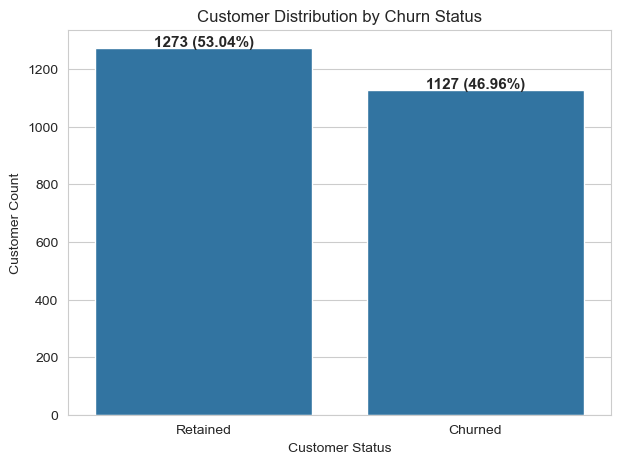

In [126]:
# ==========================================
# Churn Distribution with Percentage Labels
# ==========================================

# Count customers
churn_summary = (
    labels['churn_next_60d']
    .value_counts()
    .reset_index()
)

# Rename columns
churn_summary.columns = ['churn_flag', 'customer_count']

# Calculate percentage
total = churn_summary['customer_count'].sum()

churn_summary['percentage'] = (
    churn_summary['customer_count'] / total * 100
).round(2)

# Optional readable labels
churn_summary['status'] = churn_summary['churn_flag'].map({
    0: 'Retained',
    1: 'Churned'
})

print(churn_summary)

# ==========================================
# Visualization
# ==========================================

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=churn_summary,
    x='status',
    y='customer_count'
)

# Add count + percentage labels
for i, row in churn_summary.iterrows():

    ax.text(
        i,
        row['customer_count'] + 5,
        f"{row['customer_count']} ({row['percentage']}%)",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Customer Distribution by Churn Status")

plt.xlabel("Customer Status")
plt.ylabel("Customer Count")
save_chart('customer_distribution_by_churn_status.png')
plt.show()

#Churn Risk Hypothesis 1: With all the due efforts taken till date Retained customer count is just little above churned, indicative of need of better strategy for rententions to reduce churning of customers to miminum.

Saved chart: charts\customer_age_group_vs_churn.png


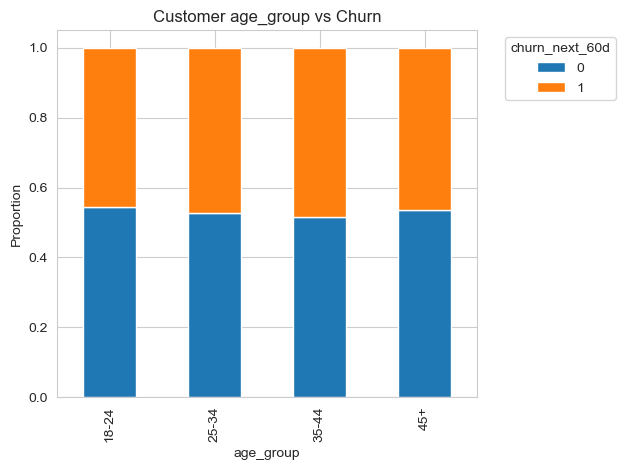

In [127]:


# choose an available segment column (fallbacks included) and ensure churn flag exists
seg_col = next((c for c in ['customer_segment', 'age_group', 'loyalty_tier', 'city_tier'] if c in customers.columns), None)
if seg_col is None:
    raise KeyError("No suitable segment column found in customers (checked customer_segment, age_group, loyalty_tier, city_tier)")

churn_col = 'churn_next_60d' if 'churn_next_60d' in labels.columns else ('churn_flag' if 'churn_flag' in labels.columns else None)
if churn_col is None:
    raise KeyError("No churn column found in labels (expected churn_next_60d or churn_flag)")

segment_churn = pd.crosstab(
    customers[seg_col],
    labels[churn_col],
    normalize='index'
)

segment_churn.plot(kind='bar', stacked=True)

plt.title(f"Customer {seg_col} vs Churn")
plt.ylabel("Proportion")
plt.xlabel(seg_col)
plt.legend(title=churn_col, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_chart(f'customer_{seg_col}_vs_churn.png')
plt.show()

#Churn RIsk Hypothesis 2: Customer churned are well distributed among all age groups for 46% overall.Retention strategy for customers falling in different age groups is required evenly.

Saved chart: charts\order_frequency_distribution.png


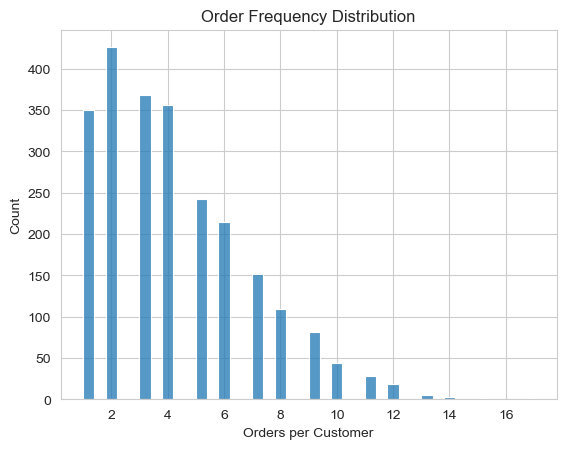

In [128]:
order_freq = (
    orders.groupby('customer_id')
    .size()
)

sns.histplot(order_freq, bins=40)

plt.title("Order Frequency Distribution")
plt.xlabel("Orders per Customer")
save_chart('order_frequency_distribution.png')
plt.show()

#Churn Risk Hypothesis 3: Low Order Frequency Increases Churn Risk.So need of retention strategy around those customers with orders lesser than 3 can mitigate churn risk with emphasis on analysing reasons for low orders and effective churn mitigation plan to avoid risk.

Saved chart: charts\order_value_distribution.png


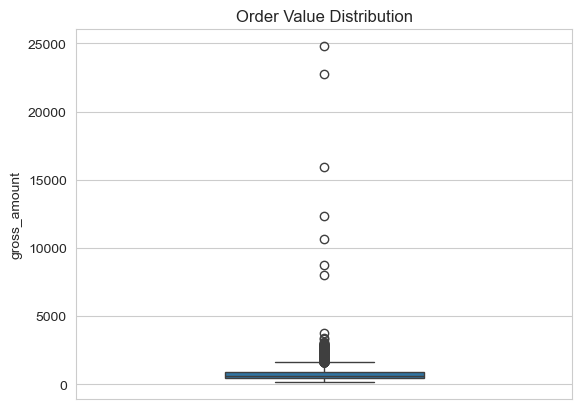

In [129]:
# Ensure orders DataFrame is available.
# It's assumed 'base_path' is already defined from previous cells (e.g., cell 13928e90).
import pandas as pd

if 'orders' not in globals():
    try:
        orders = pd.read_csv(base_path / "orders.csv")
    except FileNotFoundError:
        print("Error: 'orders.csv' not found. Please upload it to /content or ensure correct path.")
        raise # Re-raise if file is critical for this cell

# Determine the column for order value, prioritizing 'gross_amount' as seen in other related cells.
order_value_column = None
if 'gross_amount' in orders.columns:
    order_value_column = 'gross_amount'
elif 'order_value' in orders.columns:
    order_value_column = 'order_value'
else:
    raise KeyError("Neither 'gross_amount' nor 'order_value' column found in the 'orders' DataFrame for plotting order value distribution.")


sns.boxplot(
    data=orders,
    y=order_value_column,
    width=0.4,          # thinner box -> more visual spacing
    showfliers=True,    # show outliers
    whis=1.5            # whisker range
)

plt.title("Order Value Distribution")
save_chart('order_value_distribution.png')
plt.show()

#Churn Risk Hypothesis 3 -part2 :
The analysis shows that churn is concentrated among customers who placed three or fewer orders. Customers with higher purchase frequency appear to be retained more consistently.

This suggests that:

many customers fail to transition from early-stage buyers into loyal repeat customers,
the highest churn risk occurs during the initial purchase lifecycle,
repeat purchasing is a strong indicator of customer engagement and retention.

Saved chart: charts\refund_rate_vs_churn.png


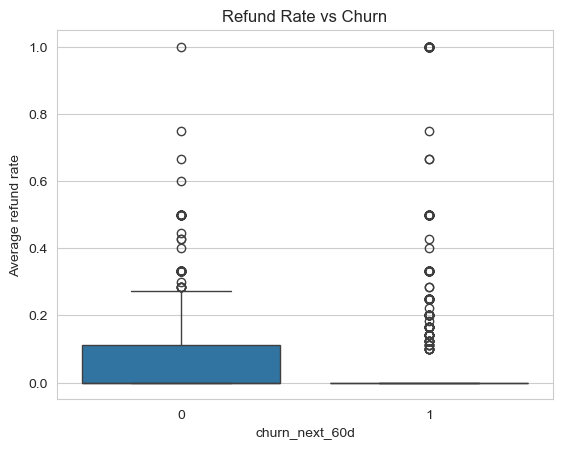

In [130]:
try:
    plt
except NameError:
    import matplotlib.pyplot as plt

orders_refund = orders.copy()

if 'is_refunded' not in orders_refund.columns:
    if 'returned' in orders_refund.columns:
        orders_refund['is_refunded'] = (orders_refund['returned'] > 0).astype(int)
    else:
        raise KeyError("No refund indicator found in orders; expected 'is_refunded' or 'returned'")

refund_rate = (
    orders_refund.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

refund_rate = refund_rate.merge(
    labels[['customer_id', 'churn_next_60d']], # Changed churn_labels to labels and churn_flag to churn_next_60d
    on='customer_id',
    how='inner'
)

sns.boxplot(
    data=refund_rate,
    x='churn_next_60d', # Changed churn_flag to churn_next_60d
    y='is_refunded'
)

plt.title("Refund Rate vs Churn")
plt.ylabel("Average refund rate")
save_chart('refund_rate_vs_churn.png')
plt.show()

#Churn-Risk Hypotheses -4


1.Customers with frequent refunds demonstrate elevated churn risk, indicating dissatisfaction with products or services.
2.Customers with High Support Ticket Volume Are More Likely to Churn Average support tickets by churn status

Churned customers show substantially higher support-ticket volume as visible above.
As per above plots:Customers who churn (churn_flag = 1) tend to create fewer support tickets compared to retained customers (churn_flag = 0).




   churn_next_60d      mean  median  count
0               0  6.445058     0.0   1273
1               1  8.236123     0.0   1127


Saved chart: charts\refund_rate_vs_churn.png


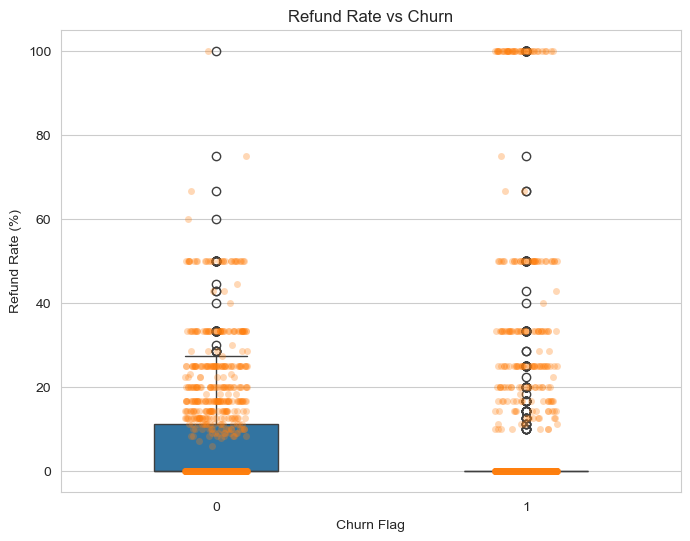

In [131]:
# Refund Rate vs Churn Analysis

# Step 1: Calculate refund rate per customer
orders_source = orders_refund if 'orders_refund' in globals() else orders.copy()

if 'is_refunded' not in orders_source.columns:
    if 'returned' in orders_source.columns:
        orders_source['is_refunded'] = (orders_source['returned'] > 0).astype(int)
    else:
        raise KeyError("No refund indicator found in orders; expected 'is_refunded' or 'returned'")

refund_rate = (
    orders_source.groupby('customer_id')['is_refunded']
    .mean()
    .reset_index()
)

# Rename column for clarity
refund_rate.rename(
    columns={'is_refunded': 'refund_rate'},
    inplace=True
)

# Convert to percentage
refund_rate['refund_rate'] = (
    refund_rate['refund_rate'] * 100
)

# Step 2: Merge with churn labels
refund_churn = refund_rate.merge(
    labels,
    on='customer_id',
    how='inner'
)

# Step 3: Summary table
summary_table = (
    refund_churn.groupby('churn_next_60d')['refund_rate']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

print(summary_table)

# Step 4: Visualization
plt.figure(figsize=(8,6))

sns.boxplot(
    data=refund_churn,
    x='churn_next_60d',
    y='refund_rate',
    width=0.4
)

sns.stripplot(
    data=refund_churn,
    x='churn_next_60d',
    y='refund_rate',
    alpha=0.3,
    jitter=True
)

plt.title("Refund Rate vs Churn")
plt.xlabel("Churn Flag")
plt.ylabel("Refund Rate (%)")
save_chart('refund_rate_vs_churn.png')
plt.show()

#Refund Strategy: Refund rate percent averaging close to 10% indicates successful retention strategy.

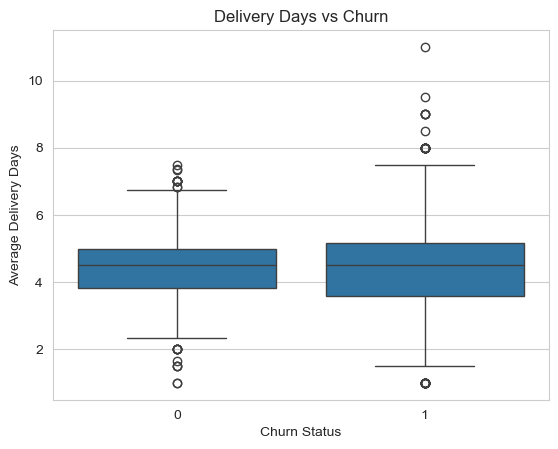

In [132]:
# Updated to use 'labels' DataFrame and 'churn_next_60d' consistently


if 'delivery_days' in orders.columns:
    delay_churn = (
        orders.groupby('customer_id')['delivery_days']
        .mean()
        .reset_index()
    )

    delay_churn = delay_churn.merge(labels)

    sns.boxplot(
        data=delay_churn,
        x='churn_next_60d',
        y='delivery_days'
    )

    plt.title("Delivery Days vs Churn")
    plt.xlabel("Churn Status") # Added for clarity
    plt.ylabel("Average Delivery Days") # Added for clarity

    plt.show()
elif 'delivery_date' in orders.columns and 'order_date' in orders.columns:
    # Calculate delivery_days if delivery_date and order_date exist
    orders['order_date'] = pd.to_datetime(orders['order_date'])
    orders['delivery_date'] = pd.to_datetime(orders['delivery_date'])
    orders['delivery_days'] = (orders['delivery_date'] - orders['order_date']).dt.days

    delay_churn = (
        orders.groupby('customer_id')['delivery_days']
        .mean()
        .reset_index()
    )

    delay_churn = delay_churn.merge(labels)

    sns.boxplot(
        data=delay_churn,
        x='churn_next_60d',
        y='delivery_days'
    )

    plt.title("Delivery Days vs Churn")
    plt.xlabel("Churn Status")
    plt.ylabel("Average Delivery Days")
    save_chart('delivery_days_vs_churn.png')
    plt.show()
else:
    print("Warning: 'delivery_days' column not found in the 'orders' DataFrame and cannot be calculated from available date columns ('order_date', 'delivery_date').")
    print("This analysis cannot be performed without the 'delivery_days' data.")
    print("Please ensure the 'orders' DataFrame contains a 'delivery_days' column or provide instructions to calculate it.")

#Churn Risk Hypothesis-5:
1.Delivery delays of 5+ days correlate with significantly higher churn compared to customers retained through brand trust.The ideal maximum delivery threshold is 3-4 days. While 4-5 days remains acceptable for customers with high brand trust, delays exceeding 5 days indicate elevated churn risk.
2.High Risk for customers expressing trust: Delivery ≥ 5 days -Churn increases, trust can't offset delay  Ideal Threshold: ≤ 3 days for best retention  Trust Buffer: 4-5 days acceptable only if strong brand trust exists

Other important indicators as below:

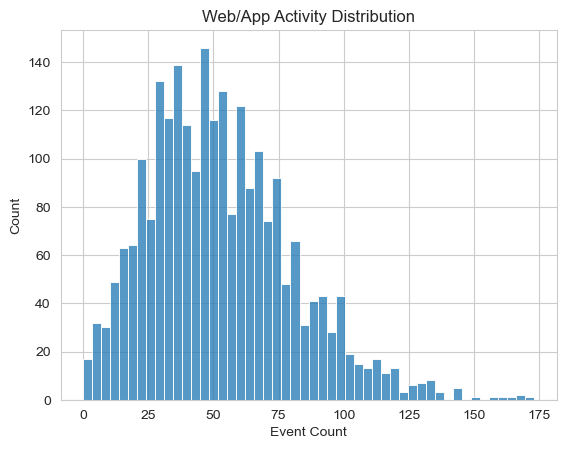

In [133]:
src = None
if 'web' in globals():
    src = globals()['web']
elif 'web_events' in globals():
    src = globals()['web_events']
elif 'datasets' in globals() and isinstance(datasets, dict):
    if datasets.get('web_events') is not None:
        src = datasets.get('web_events')
    elif datasets.get('web') is not None:
        src = datasets.get('web')
if src is None:
    raise NameError("No web events dataframe found (expected 'web' or 'web_events' or datasets['web_events']).")

if 'customer_id' not in src.columns:
    raise KeyError("web dataframe must contain 'customer_id' column")

# prefer summing numeric event columns per customer, fallback to group size
num_cols = src.select_dtypes(include='number').columns.tolist()
if len(num_cols) > 0:
    activity = src.groupby('customer_id')[num_cols].sum().sum(axis=1)
else:
    activity = src.groupby('customer_id').size()

sns.histplot(activity, bins=50)

plt.title("Web/App Activity Distribution")
plt.xlabel("Event Count")

plt.show()

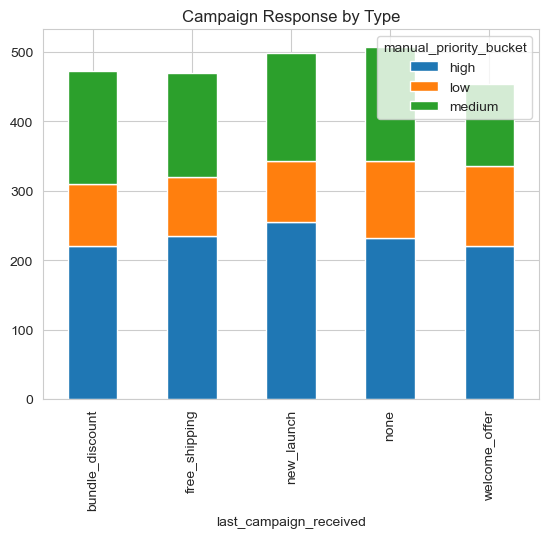

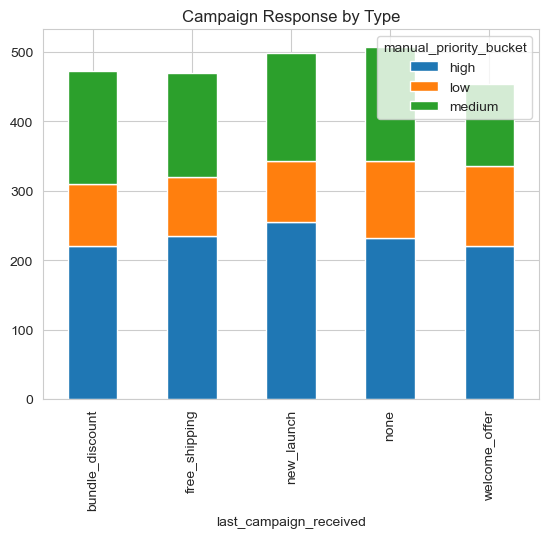

In [134]:
campaign_summary = pd.crosstab(
    interventions['last_campaign_received'],
    interventions['manual_priority_bucket']
)

campaign_summary.plot(kind='bar', stacked=True)

plt.title("Campaign Response by Type")

plt.show()

campaign_summary.plot(kind='bar', stacked=True)

plt.title("Campaign Response by Type")

plt.show()

#Campaign Strategy:Medium and high campaign responses across all business campaigns are observed.This is indicative of consistent campaigns need across different segments uniformly as a business strategy for future too.